# Section B

## Qno 7 and 8

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [57]:
df = pd.read_csv("StPerformData.csv")

In [58]:
df.head()

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f


In [59]:
df.shape

(25000, 16)

The dataset has 25000 rows and 16 columns

In [60]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
school_type,0
parent_education,0
study_hours,0
attendance_percentage,0
internet_access,0
travel_time,0
extra_activities,0


There is no null value in this dataset.

The column "student_id" is not a feature. That's why It is deleted from dataset.

In [61]:
del df["student_id"]

In [62]:
df.describe()

,age,study_hours,attendance_percentage,math_score,science_score,english_score,overall_score
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,16.482760,4.253224,75.084084,63.785944,63.745320,63.681948,64.006172
std,1.703895,2.167541,14.373171,20.875262,20.970529,20.792693,18.932025
min,14.000000,0.500000,50.000000,0.000000,0.000000,0.000000,14.500000
25%,15.000000,2.400000,62.800000,48.300000,48.200000,48.300000,49.000000
50%,16.000000,4.300000,75.100000,64.100000,64.100000,64.200000,64.200000
75%,18.000000,6.100000,87.500000,80.000000,80.000000,80.000000,79.000000
max,19.000000,8.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [63]:
col = ["age",	"study_hours"	,"attendance_percentage"	,"math_score"	,"science_score"	,"english_score"	,"overall_score"]

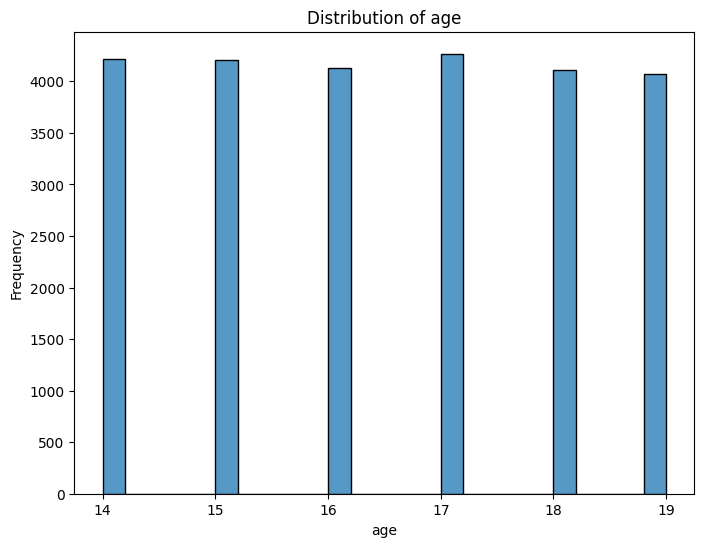

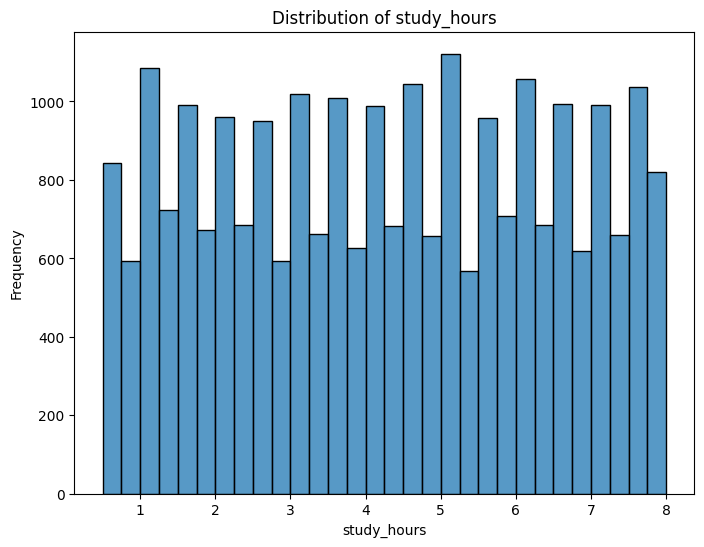

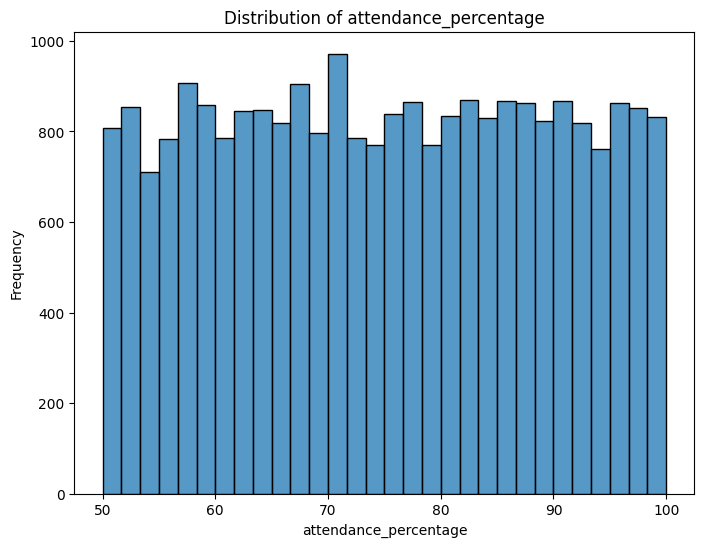

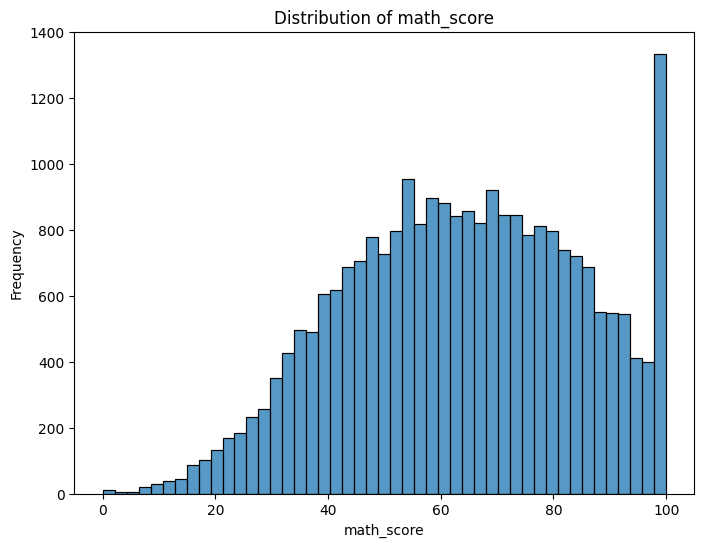

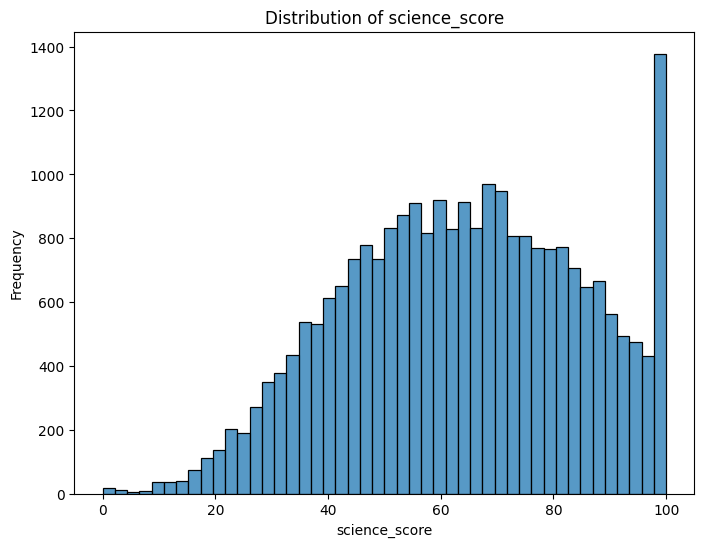

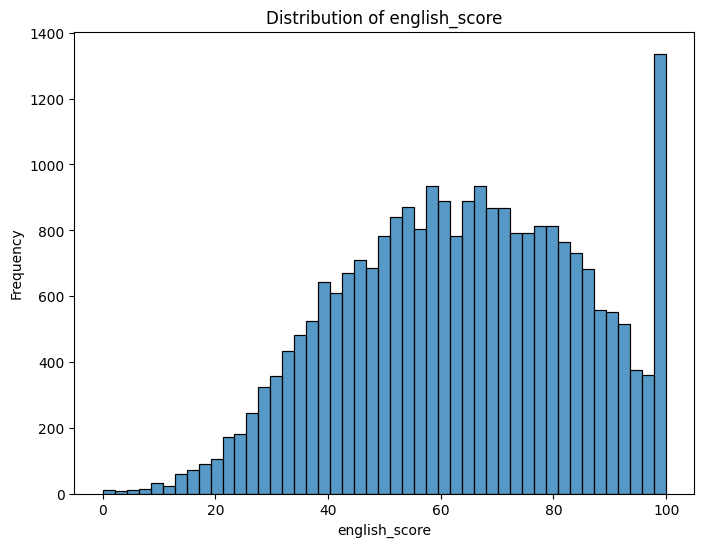

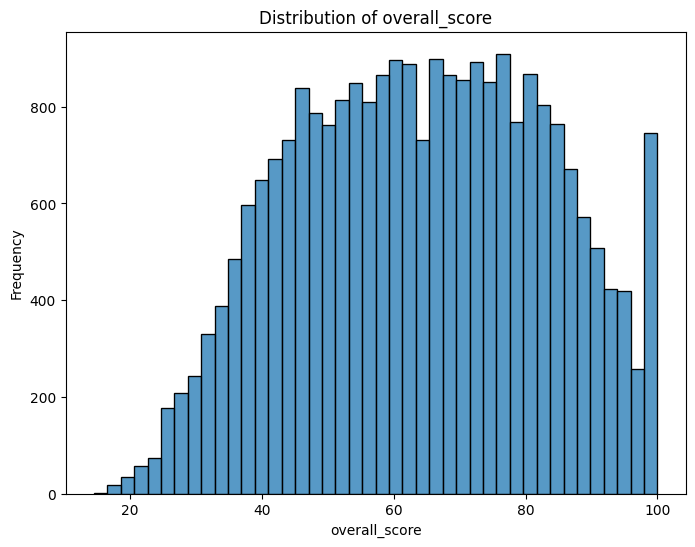

In [64]:
for x in col:
  plt.figure(figsize=(8, 6))
  sns.histplot(x=df[x])
  plt.title(f'Distribution of {x}')
  plt.xlabel(x)
  plt.ylabel('Frequency')
  plt.show()

For continous data:
It is found that:
The column "age", "study_hours", "attendance_percentage" have nearly uniformly distributed data. While the columns "math_score"	,"science_score"	,"english_score"	and "overall_score" have nearly normally distributed data.

In [65]:
uniform_col = ["age", "study_hours", "attendance_percentage"]
normally_distributed_col = ["math_score", "science_score", "english_score", "overall_score"]

In [66]:
skew_list = []
for x in uniform_col:
  skewness = df[x].skew()
  skew_list.append(skewness)
skew_list

[np.float64(0.010028934014971453),
 np.float64(-0.007268482021282501),
 np.float64(-0.0027465192809432793)]

In [67]:
skew_list = []
for x in normally_distributed_col:
  skewness = df[x].skew()
  skew_list.append(skewness)
skew_list

[np.float64(-0.14801632309842638),
 np.float64(-0.13529798986156394),
 np.float64(-0.14146839500848793),
 np.float64(-0.04451196893809452)]

THe skewness from above code clearly shows that some columns are normally distributed while some uniformly distributed because the skewness is nearly zero.

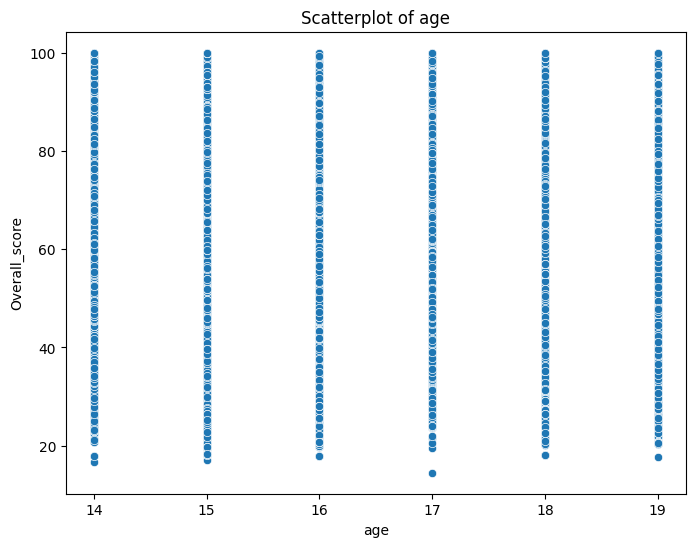

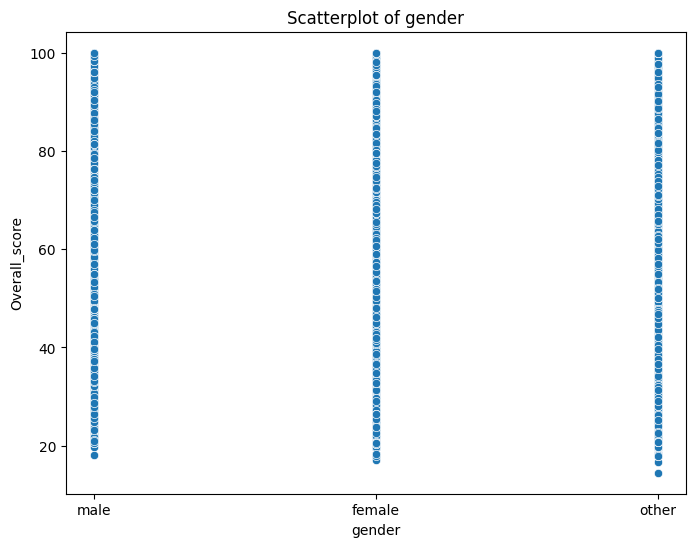

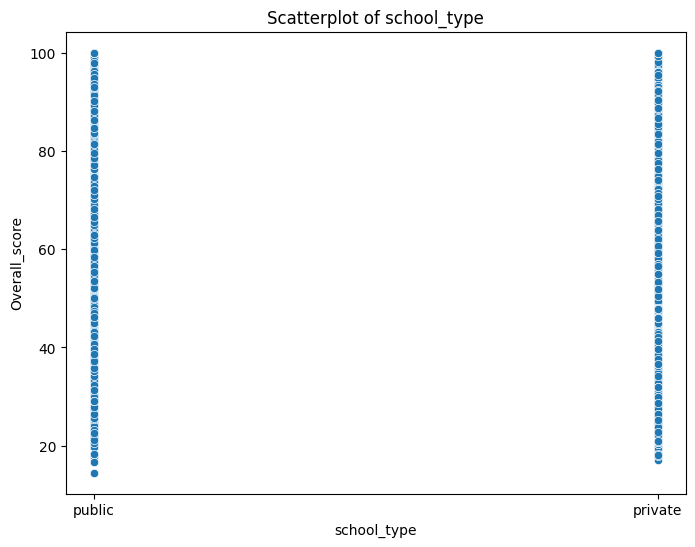

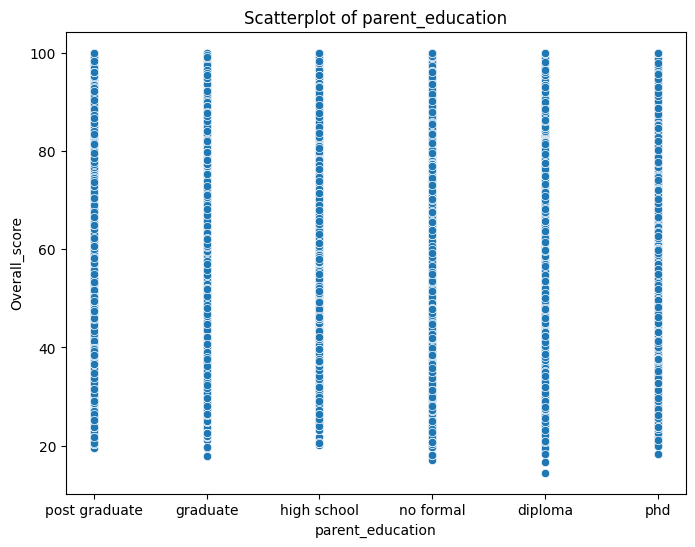

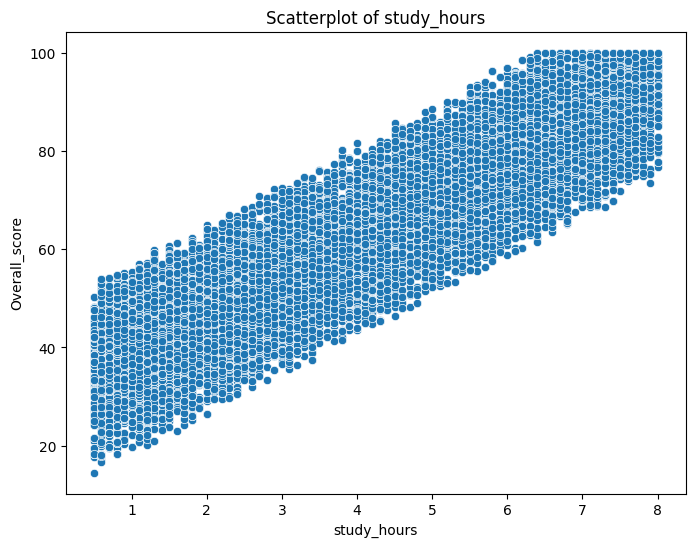

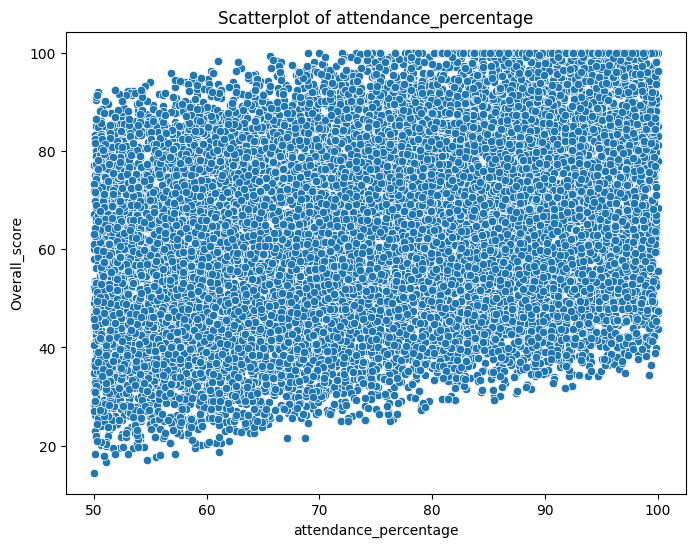

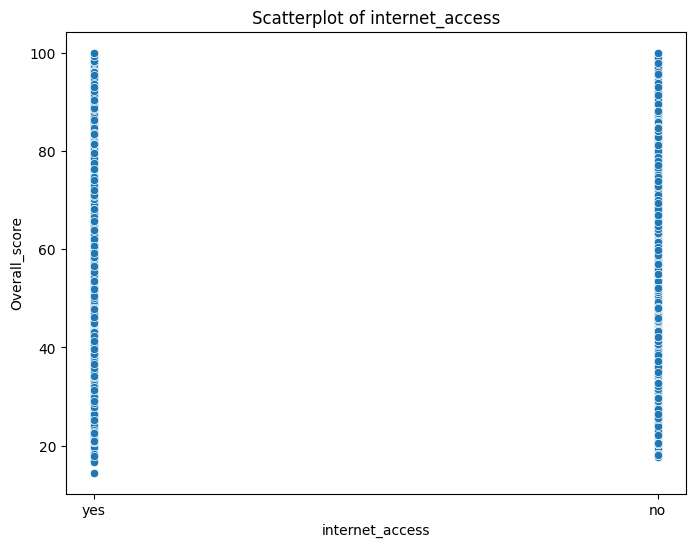

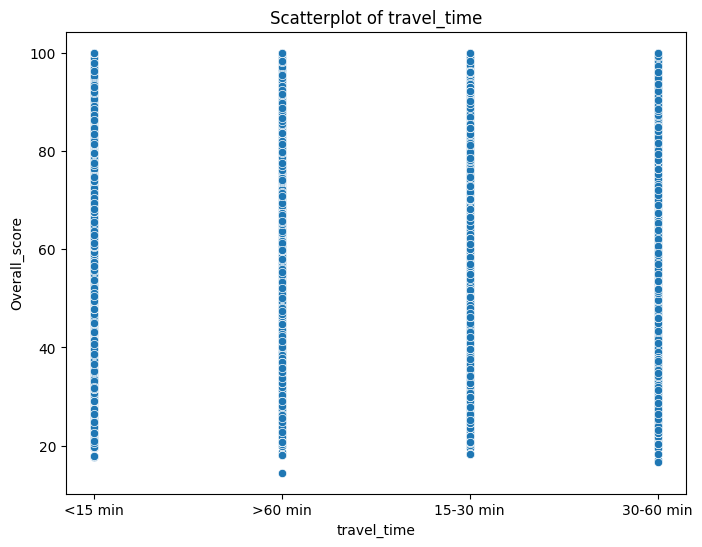

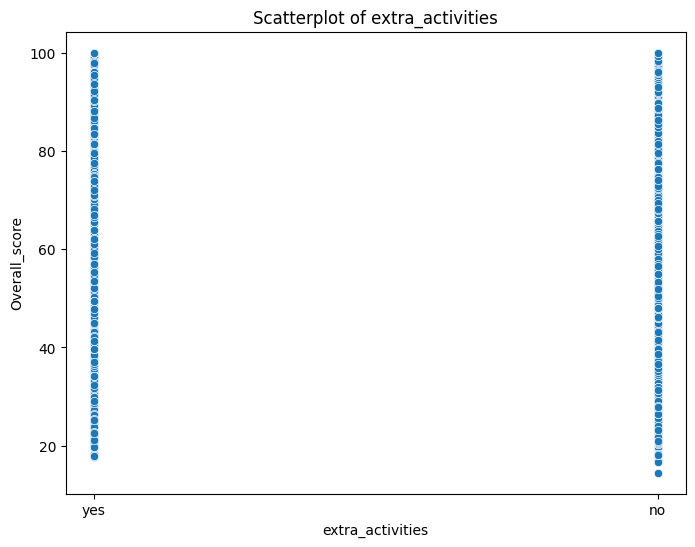

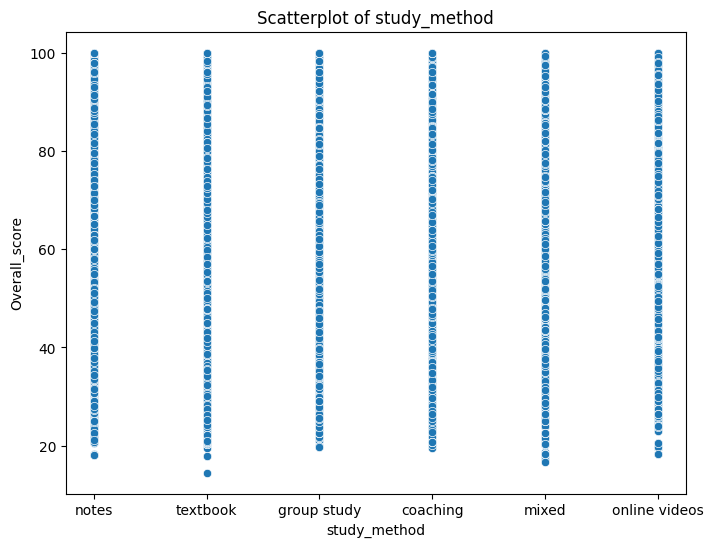

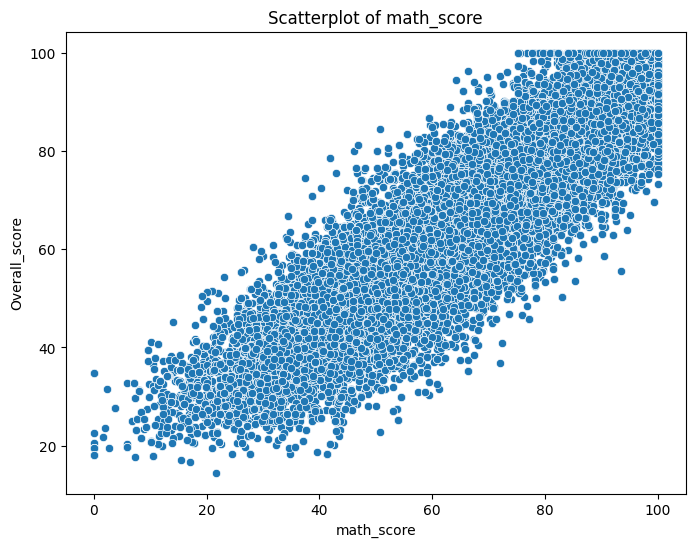

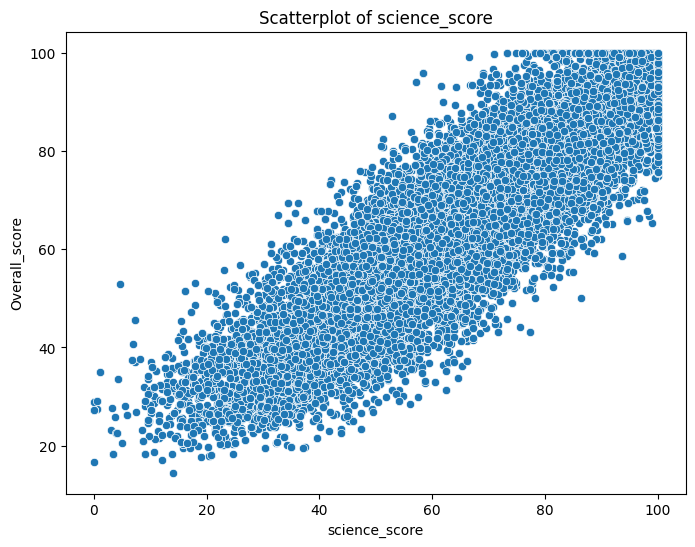

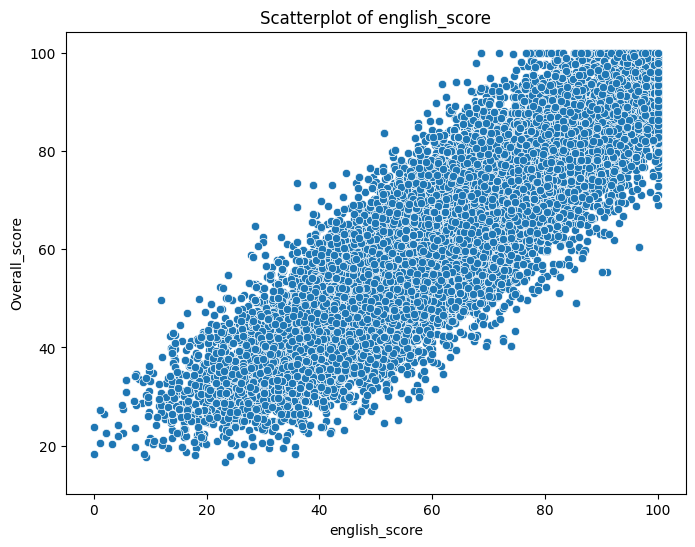

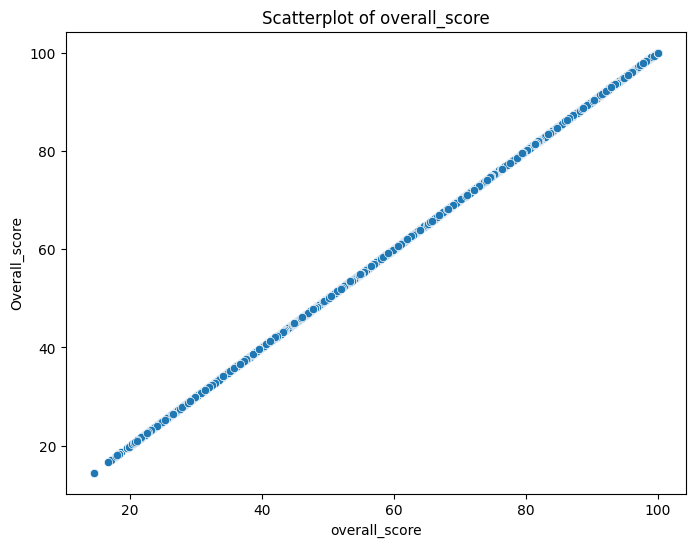

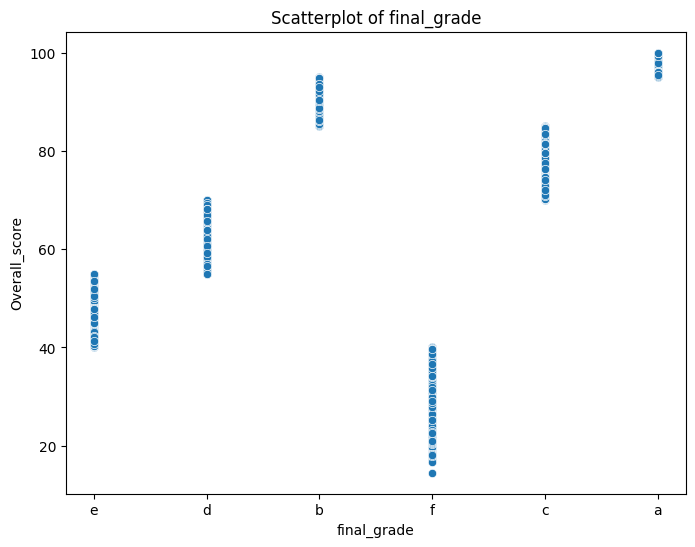

In [68]:
for x in df.columns:
  plt.figure(figsize=(8, 6))
  sns.scatterplot(x=df[x], y=df["overall_score"])
  plt.title(f'Scatterplot of {x}')
  plt.xlabel(x)
  plt.ylabel('Overall_score')
  plt.show()

From scatterplot, it is found that the column study_hours, math_score, science_Score and english_score are linearly related with overall_Score

([<matplotlib.patches.Wedge at 0x7ceca8ccf0e0>,
 [Text(0.7718322769960512, 0.7837569369307625, 'd'),
  Text(-0.7810364162621244, 0.7745851253880479, 'c'),
  Text(-0.83725394885631, -0.7134464416650459, 'e'),
  Text(0.23901365908272992, -1.0737189905985107, 'f'),
  Text(0.8812274273695381, -0.6583602518770902, 'b'),
  Text(1.087412885362, -0.1659313615585972, 'a')],
 [Text(0.42099942381602784, 0.42750378378041587, '25.2%'),
  Text(-0.42601986341570414, 0.4225009774843897, '24.6%'),
  Text(-0.45668397210344175, -0.38915260454457046, '22.7%'),
  Text(0.13037108677239814, -0.585664903962824, '11.8%'),
  Text(0.4806695058379298, -0.35910559193295827, '10.8%'),
  Text(0.5931343011065454, -0.09050801539559845, '4.8%')])

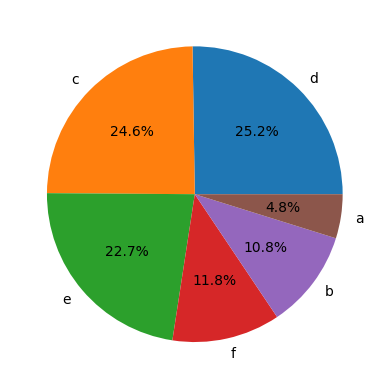

In [96]:
plt.pie(x=df["final_grade"].value_counts(), labels=df["final_grade"].value_counts().index, autopct='%1.1f%%')

The student got "D" grade more while some of them got "A" grade.

In [69]:
lin_col = ["study_hours", "math_score", "science_score", "english_score", "overall_score"]

In [70]:
corr = df[lin_col].corr()
corr

,study_hours,math_score,science_score,english_score,overall_score
study_hours,1.000000,0.802321,0.805073,0.803718,0.905771
math_score,0.802321,1.000000,0.784111,0.786315,0.884555
science_score,0.805073,0.784111,1.000000,0.783951,0.885748
english_score,0.803718,0.786315,0.783951,1.000000,0.883334
overall_score,0.905771,0.884555,0.885748,0.883334,1.000000


<Axes: >

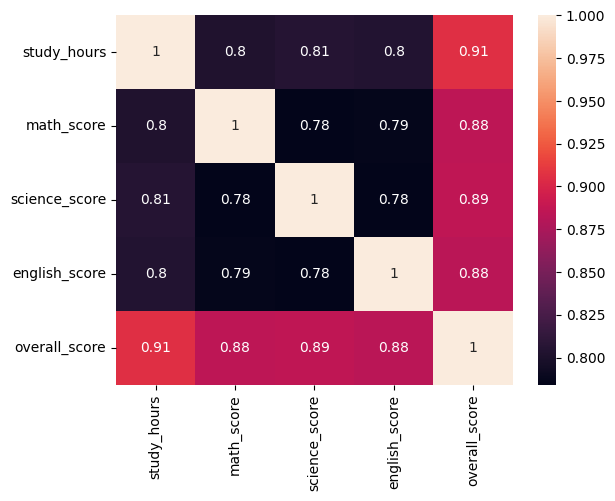

In [71]:
sns.heatmap(corr, annot=True)

From heatmap, It is found that:
The column "study_hours" is highly correlated with overall_score column. That's why I am finding relationship between "study_hours" and "overall_score"

In [72]:
X = df[["study_hours"]]
y = df["overall_score"]

In [73]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [74]:
lr = LinearRegression()


In [75]:
model = lr.fit(x_train, y_train)

In [76]:
predict = model.predict(x_test)

In [77]:
model.score(x_test, y_test)

0.8216704306385485

In [78]:
intercept = model.intercept_
slope = model.coef_

In [88]:
print("The equation of best fit line is:")
print(f"Y = {slope[0]}X + {intercept}")

The equation of best fit line is:
Y = 7.9029298944448545X + 30.38458235091398


In [93]:
print("MAE\t\t", metrics.mean_absolute_error(y_test, predict))
print("MSE\t\t", metrics.mean_squared_error(y_test, predict))
print("RMSE\t\t", metrics.mean_squared_error(y_test, predict)**0.5)



MAE		 6.561427009938089
MSE		 64.40107287469284
RMSE		 8.02502790491677


It is found that the R^2 is 0.82 which is a good score for the selected variables. And the equation of liine is : Y = 7.9X + 30.38